# Churn prediction analysis
## Table of Contents:
1. Importing libraries
2. Initial inspection
3. Data cleaning
4. Exploratory Data Analysis (EDA)
    - 4.1. Target variable
    - 4.2. Numerical variables
        - 4.2.1. Descriptive statistics, histograms, box plots
        - 4.2.2. Outliers check
        - 4.2.3. Relationship with churn
    - 4.3. Categorical variables
        - 4.3.1. Demographic variables
        - 4.3.2. Services variables
        - 4.3.3. Customer account information
    - 4.4. Correlation analysis
5. Data preprocessing
6. Churn prediction analysis
    - 6.1. Baseline - Logistic regression
    - 6.2. Logistic Regression with CV tuning
    - 6.3. Random Forest
        - 6.3.1. Random Forest without TotalCharges variable
    - 6.4. XGBoost
7. Results

# 1. Importing libraries and data

In [106]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from dython.nominal import associations
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from sklearn.metrics import RocCurveDisplay
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
import shap

In [107]:
df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

Information about the dataset can be found [here](https://www.kaggle.com/datasets/blastchar/telco-customer-churn/data)

Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

The data set includes information about:

- Customers who left within the last month – the column is called Churn
- Services that each customer has signed up for – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- Customer account information – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- Demographic info about customers – gender, age range, and if they have partners and dependents

# 2. Initial inspection <a class="anchor" id="initial-inspection"></a>

In [108]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [109]:
df.shape

(7043, 21)

In [110]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# 3. Data cleaning

In [111]:
# convert TotalCharges column to float
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [112]:
# convert SeniorCitizen column to str for consistency of categorical variables
df["SeniorCitizen"]= df["SeniorCitizen"].map({0: "No", 1: "Yes"})

In [113]:
# check for missing values
df.isnull().sum()

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [114]:
df[np.isnan(df['TotalCharges'])]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,No,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,No,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,No,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,No,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,No,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,No,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [115]:
# check that all rows with tenure = 0 have NaN in TotalCharges
df[df['tenure'] == 0].equals(df[np.isnan(df['TotalCharges'])])

True

Since there are only 11 (out of 7000+) rows with NaN, and their tenure is zero, we can delete them without compromising the data for the purposes of churn prediction.

In [116]:
df = df.dropna()
df.shape

(7032, 21)

In [117]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

# 4 Exploratory Data Analysis (EDA)

## 4.1 Target variable

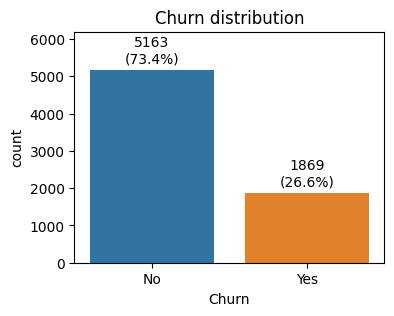

In [118]:
plt.figure(figsize=(4, 3))
ax = sns.countplot(x='Churn', data=df, hue='Churn')
total = df["Churn"].value_counts().sum()

for container in ax.containers:
    labels = [f"{v.get_height():.0f}\n({v.get_height()/total:.1%})"for v in container]
    ax.bar_label(container, labels=labels, label_type="edge", padding=3)

plt.ylim(0, max(df["Churn"].value_counts()) * 1.2)
plt.title('Churn distribution')
plt.savefig("images/churn_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

Class imbalance is observed: churned customers make up 26.6% of the dataset, while non-churned make up 73.4%. Thus, this situation should be addressed by choosing F1-score or ROC-AUC metrics when measuring performance of the prediction models.

## 4.2 Numerical variables
Exploring numerical columns first: descriptive statistics, histograms, box plots, relationship with churn & outliers

### 4.2.1 Descriptive statistics, histograms, box plots

In [119]:
# descriptive statistics
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

df[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
tenure,7032.0,32.421786,24.545260,1.00,9.0000,29.000,55.0000,72.00
MonthlyCharges,7032.0,64.798208,30.085974,18.25,35.5875,70.350,89.8625,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.4500,1397.475,3794.7375,8684.80


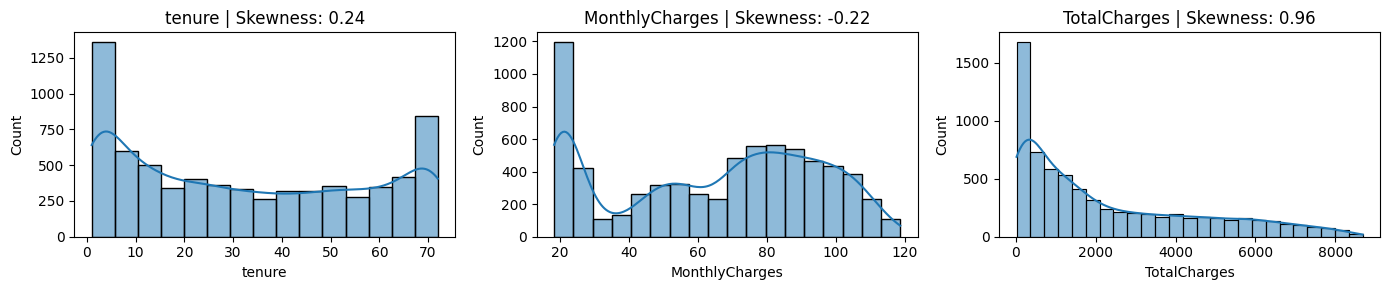

In [120]:
# histograms
plt.figure(figsize=(14, len(numerical_columns)))
for idx, col in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), idx)
    sns.histplot(df[col], kde=True)
    plt.title(f"{col} | Skewness: {round(df[col].skew(), 2)}")

plt.tight_layout()
plt.show()

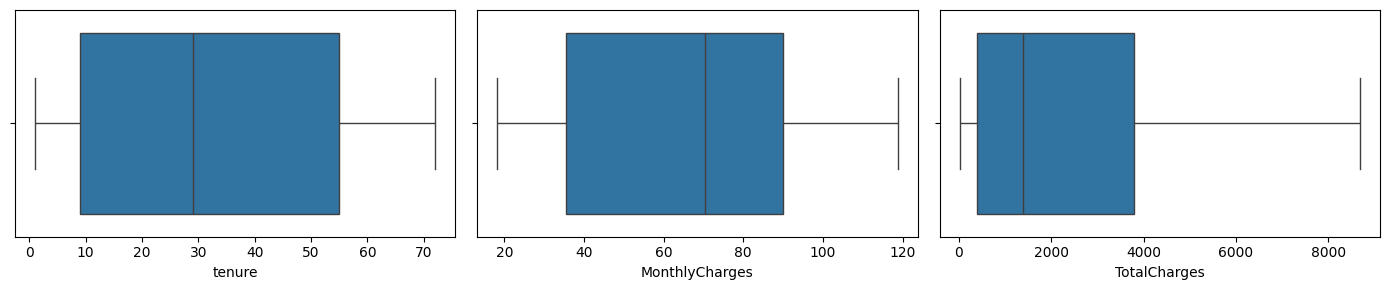

In [121]:
# box plots
plt.figure(figsize=(14, len(numerical_columns)))
for idx, col in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), idx)
    sns.boxplot(x=df[col])

plt.tight_layout()
plt.show()

### 4.2.2 Outliers check

Box plots confirm no extreme values for tenure and MonthlyCharges: their ranges align with business-defined bounds (1–72 months and $18–$119 respectively), and no points fall outside the whiskers. 
TotalCharges shows a long right tail - expected for a derived variable (approximately $tenure \cdot MonthlyCharges$, as seen below), but worth a formal check given the skew.  Since the data is non-normal, modified Z-score (robust to skew) is preferred over the standard Z-score.

$$modified\ z-score = \frac{0.6745 \cdot (x_i - \tilde x)}{MAD}$$
where: 
$x_i$ - the individual data point, $\tilde x$ - median of the dataset, MAD - Median Absolute Deviation $median(|x_i - \tilde x|)$, 0.6745: a scaling constant used to standardize the MAD so it accurately matches the standard deviation of a normal distribution. 

Absolute modified Z-scores greater than 3.5 are generally flagged as potential outliers.

<Axes: xlabel='tenure', ylabel='TotalCharges'>

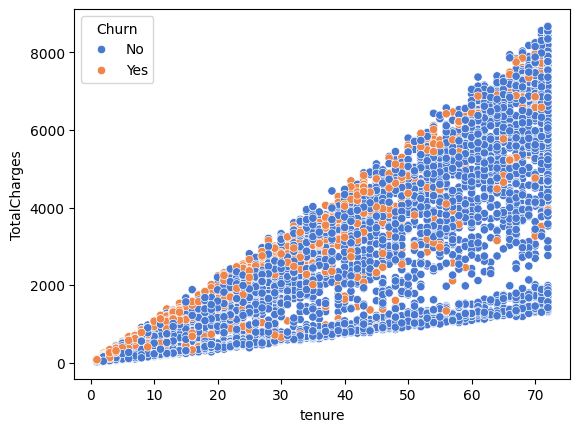

In [122]:
# scatter plot for tenure - TotalCharges relationship 
sns.scatterplot(
    data=df,
    x='tenure',
    y='TotalCharges',
    hue='Churn',
    palette='muted'
)

In [123]:
expected = df['tenure'] * df['MonthlyCharges']

(df['TotalCharges'] - expected).describe()

count    7032.000000
mean        0.153193
std        67.255326
min      -370.850000
25%       -28.650000
50%         0.000000
75%        28.700000
max       373.250000
dtype: float64

In [124]:
# create new df for TotalCharges
data = pd.DataFrame()
data['value'] = df['TotalCharges']
data['tenure'] = df['tenure']

# Calculate modified z-Score
median = data['value'].median()
data['mad'] = np.median(np.abs(data['value'] - median))
data['modified_z_score'] = 0.6745 * (data['value'] - median) / data['mad']

# Flag anomalies where Z-Score threshold > 3.5
data['is_outlier_median'] = data['modified_z_score'].abs() > 3.5
data[data['is_outlier_median']].describe().T

,count,mean,std,min,25%,50%,75%,max
value,136.0,8101.162868,2.432558e+02,7746.700000,7886.062500,8058.700000,8309.062500,8684.800000
tenure,136.0,71.272059,1.363367e+00,66.000000,71.000000,72.000000,72.000000,72.000000
mad,136.0,1222.800000,2.282142e-13,1222.800000,1222.800000,1222.800000,1222.800000,1222.800000
modified_z_score,136.0,3.697774,1.341806e-01,3.502251,3.579124,3.674351,3.812452,4.019709


As seen in the table above, all potential outliers correspond to long-tenure customers with naturally accumulated spending rather than anomalies; therefore, no removal is needed. 

In [125]:
# sanity check
print((df[['tenure', 'MonthlyCharges', 'TotalCharges']] < 0).sum())

tenure            0
MonthlyCharges    0
TotalCharges      0
dtype: int64


In [126]:
print(df[(df['TotalCharges'] == 0) & (df['tenure'] > 0)])

Empty DataFrame
Columns: [customerID, gender, SeniorCitizen, Partner, Dependents, tenure, PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies, Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges, Churn]
Index: []

[0 rows x 21 columns]


### 4.2.3 Relationship with churn

- boxplot by churn
- violinplot by churn
- KDE by churn

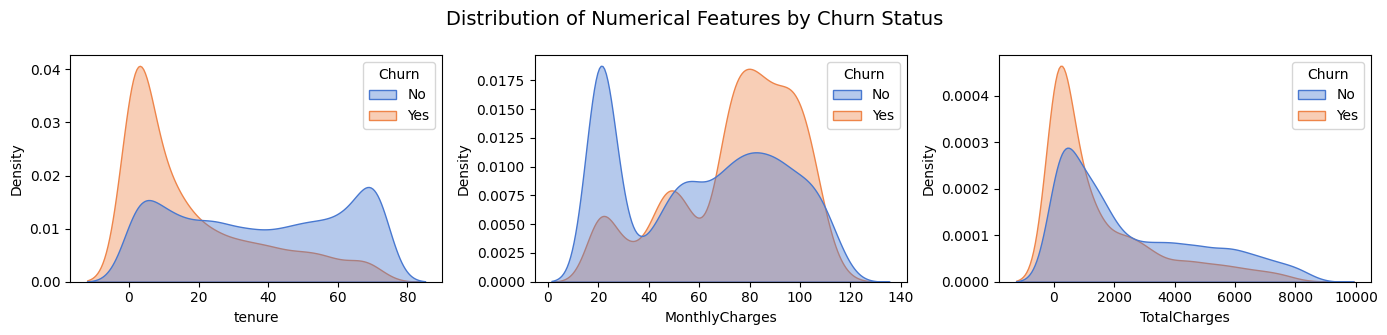

In [127]:
# kde plots
plt.figure(figsize=(14, len(numerical_columns)))
for idx, col in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), idx)
    sns.kdeplot(data=df, x=col, hue="Churn", fill = True, common_norm=False, palette='muted', alpha=0.4)
plt.tight_layout()
plt.suptitle('Distribution of Numerical Features by Churn Status', fontsize=14, y=1.1)
plt.show()

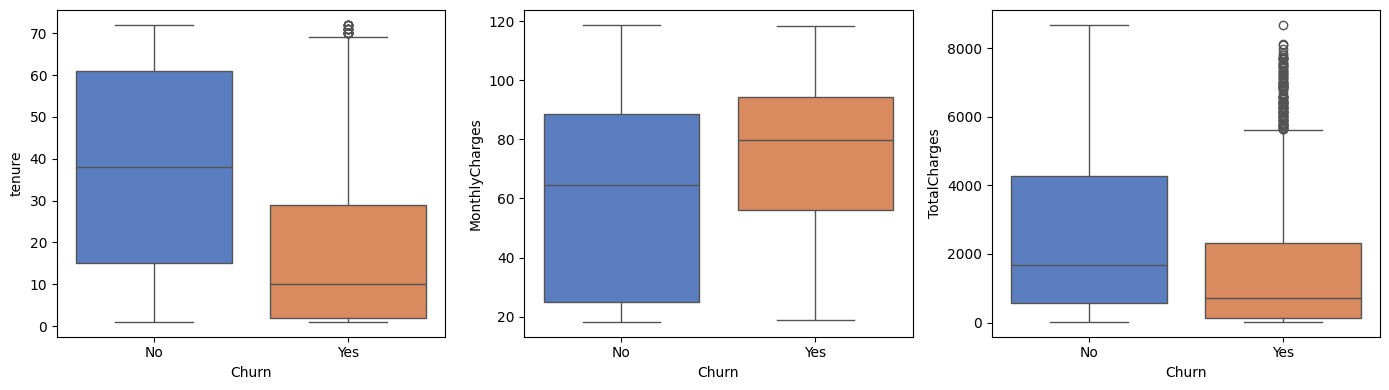

In [128]:
# box plots
plt.figure(figsize=(14, len(numerical_columns)+1 ))
for idx, col in enumerate(numerical_columns, 1):
    plt.subplot(1, len(numerical_columns), idx)
    sns.boxplot(x=df['Churn'], y=df[col], hue=df['Churn'], palette='muted')

plt.tight_layout()
plt.show()

- Tenure: customers with lower tenure have a higher churn rate. The median tenure of retained customers is approximately 3.5 times higher than that of churned customers.
- Monthly charges: customers with higher monthly charges have a higher churn rate. 
- Total charges: customers with lower total charges have a higher churn rate.

Churned customers tend to have shorter tenure and lower total charges, suggesting early churn, while also facing higher monthly charges.

## 4.3 Categorical variables

In [129]:
# list of categorial variables, with customerID deleted
categorical_columns = df.select_dtypes(include=["str"]).columns
categorical_columns = categorical_columns.drop('customerID').drop('Churn')
categorical_columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')

### 4.3.1 Demographic variables

In [130]:
demographics_columns = categorical_columns[0:4]
print(demographics_columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents'], dtype='str')


In [131]:
def distribution_percentage_chart(axes, columns):
    for ax, col in zip(axes.flat, columns):

        pct = (df[col].value_counts(normalize=True).mul(100).sort_values(ascending=False).reset_index())
        pct.columns = [col, "percentage"]

        sns.barplot(data=pct, x=col, y="percentage", ax=ax, palette="Blues_r", hue=col)

        for container in ax.containers:
            ax.bar_label(container, fmt="%.1f%%", padding=3)
        ax.set_title(col, fontsize=12)
        ax.set_ylim(0, 100)
        ax.set_xlabel("")

In [132]:
def distribution_percentage_by_churn_chart_v2(axes, columns):
    for ax, col in zip(axes.flat, columns):
        pivot = (df.groupby(col)['Churn'].value_counts(normalize=True).mul(100).rename('percentage').reset_index().
                 pivot(index=col,columns='Churn',values='percentage'))
        order = df[col].value_counts().index
        pivot = pivot.loc[order]
        colors = sns.color_palette("muted", 2)
        pivot.plot(kind='bar', stacked=True, ax=ax, color=colors)
        ax.set_title(col)
        ax.set_ylim(0, 100)
        ax.set_xlabel("")
        ax.get_legend().remove()
        ax.tick_params(axis='x', rotation=0)
        for container in ax.containers:
            labels = [f"{v.get_height():.1f}%" if v.get_height() > 5 else "" for v in container]
            ax.bar_label(container,labels=labels,label_type='center')    
    handles, labels = axes.flat[0].get_legend_handles_labels()
    fig.legend(handles, labels, title="Churn", loc="upper center", ncol=2, bbox_to_anchor=(0.51, 0.95))

In [133]:
alpha = 0.05
def chi2_test(columns):
    results = []
    
    for col in columns:
        crosstab = pd.crosstab(df[col], df['Churn'])
        chi2, p_value, dof, expected = chi2_contingency(crosstab)
        results.append({"feature": col, "p_value": p_value, "dependent": p_value <= alpha})

    return pd.DataFrame(results).sort_values("p_value").round(3)

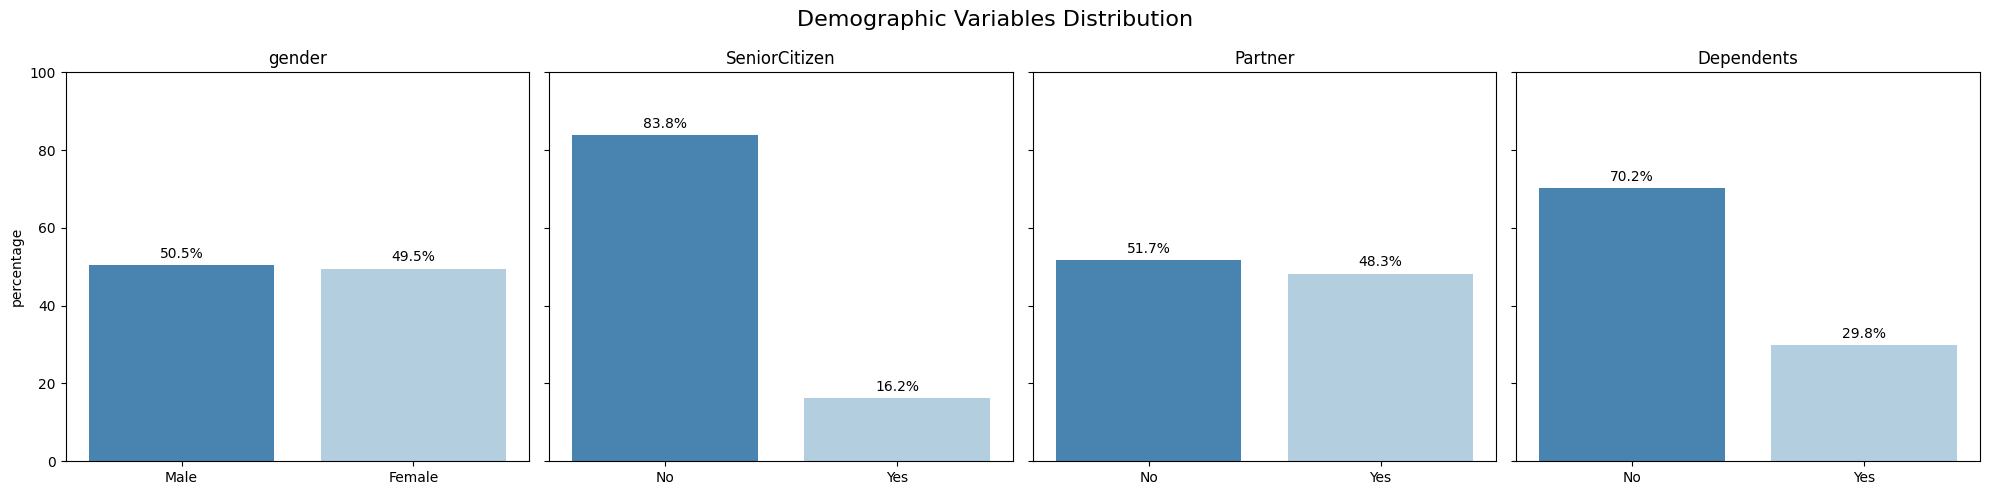

In [134]:
# distribution
fig, axes = plt.subplots(1, len(demographics_columns),figsize=(5 * len(demographics_columns), 5),sharey=True)

distribution_percentage_chart(axes, demographics_columns)

plt.suptitle("Demographic Variables Distribution", fontsize=16)

plt.tight_layout()
plt.show()

- Gender and Partner variables show almost equal distributions. 
- 83.8% of customers in the dataset are not senior, and 70.2% do not have dependents

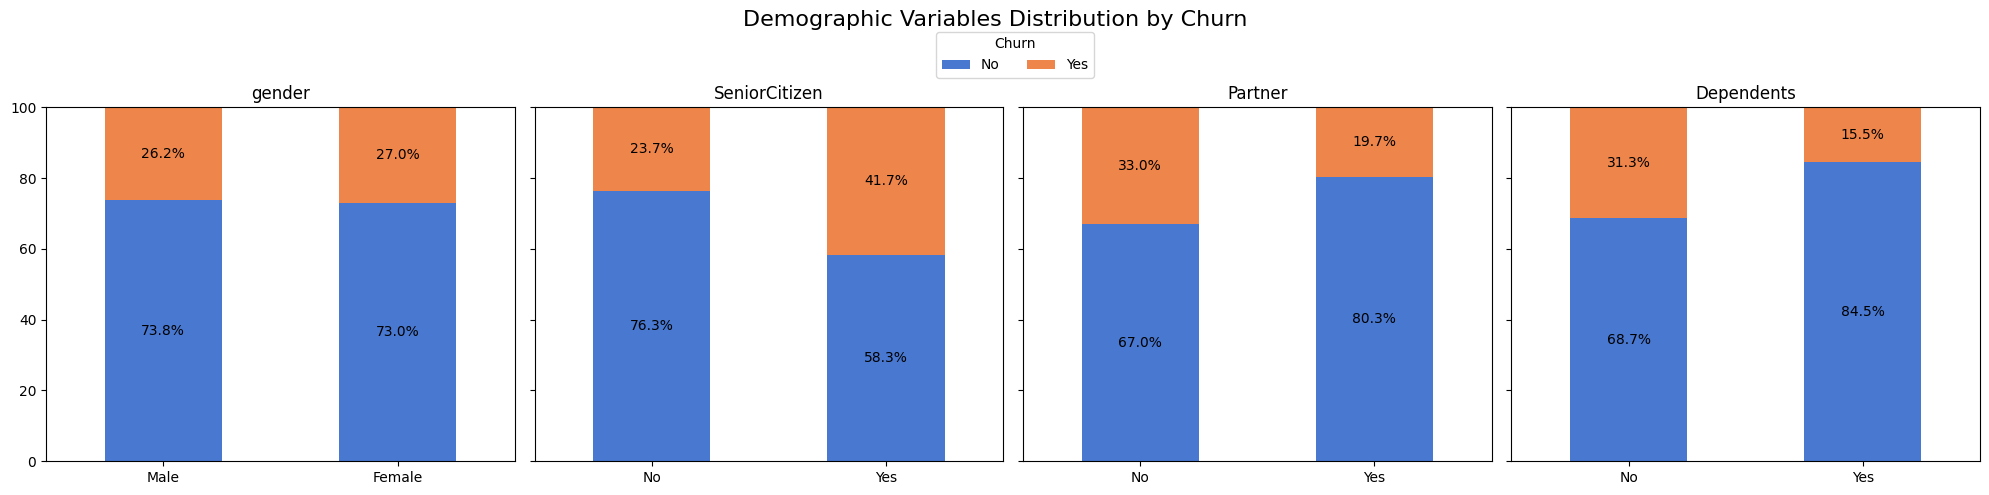

In [135]:
# distribution by churn
fig, axes = plt.subplots(1,len(demographics_columns),figsize=(5 * len(demographics_columns), 5),sharey=True)

distribution_percentage_by_churn_chart_v2(axes, demographics_columns)

plt.suptitle("Demographic Variables Distribution by Churn", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

- Gender: almost equal distributions of churn across both genders
- SeniorCitizen: the churn rate is higher in Senior demographics by 18 p.p
- Partner status: customers with a partner have a lower churn rate (19.7% vs 33%)
- Dependents: customers without dependents have a double churn rate of those with dependents (31.3% vs 15.5%)

In [136]:
print(f"Chi-square test of demographics variables & Churn at {1-alpha:.0%} significance level")
chi2_test(demographics_columns)

Chi-square test of demographics variables & Churn at 95% significance level


,feature,p_value,dependent
3,Dependents,0.00,True
1,SeniorCitizen,0.00,True
2,Partner,0.00,True
0,gender,0.49,False


### 4.3.2 Services variables

In [137]:
print(f"Categorical variables: {categorical_columns}")
services_columns = categorical_columns[4:-3]
print(f"Services variables: {services_columns}")

Categorical variables: Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
Services variables: Index(['PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies'],
      dtype='str')


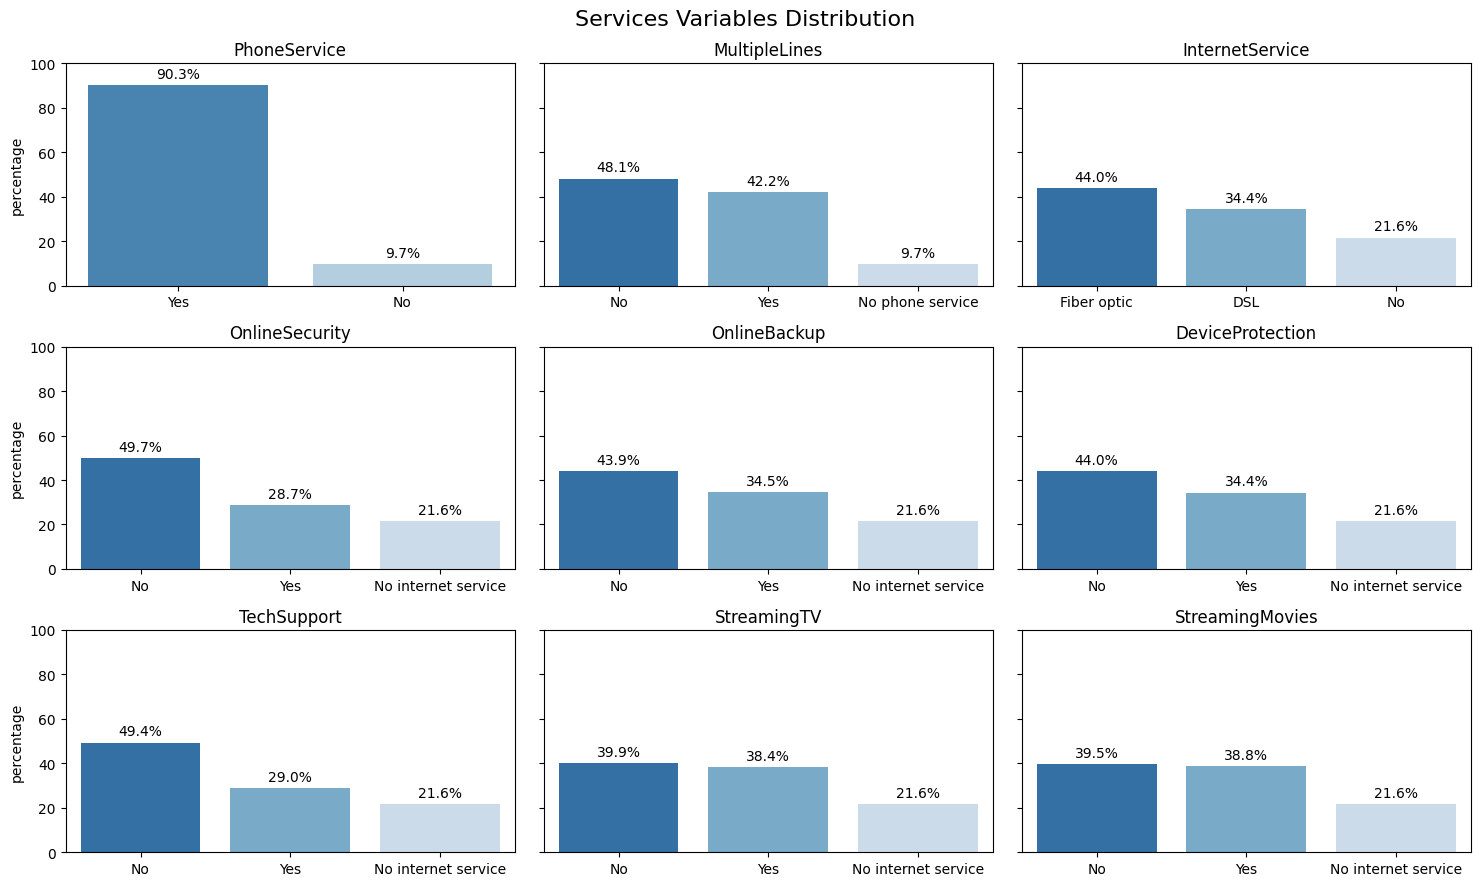

In [138]:
# distribution
fig, axes = plt.subplots(3, 3, figsize = (15,9), sharey=True)

distribution_percentage_chart(axes, services_columns)

plt.suptitle("Services Variables Distribution", fontsize=16)

plt.tight_layout()
plt.show()

- Phone service: more than 90% of the customers in the dataset use phone service, and almost half of them have multiple phone lines
- Internet service: 78.4% of customers use internet service, with a little more than a half of them choosing fiber optic
- Additional services: range from 28.7% (online security) to 38.8% (streaming movies)

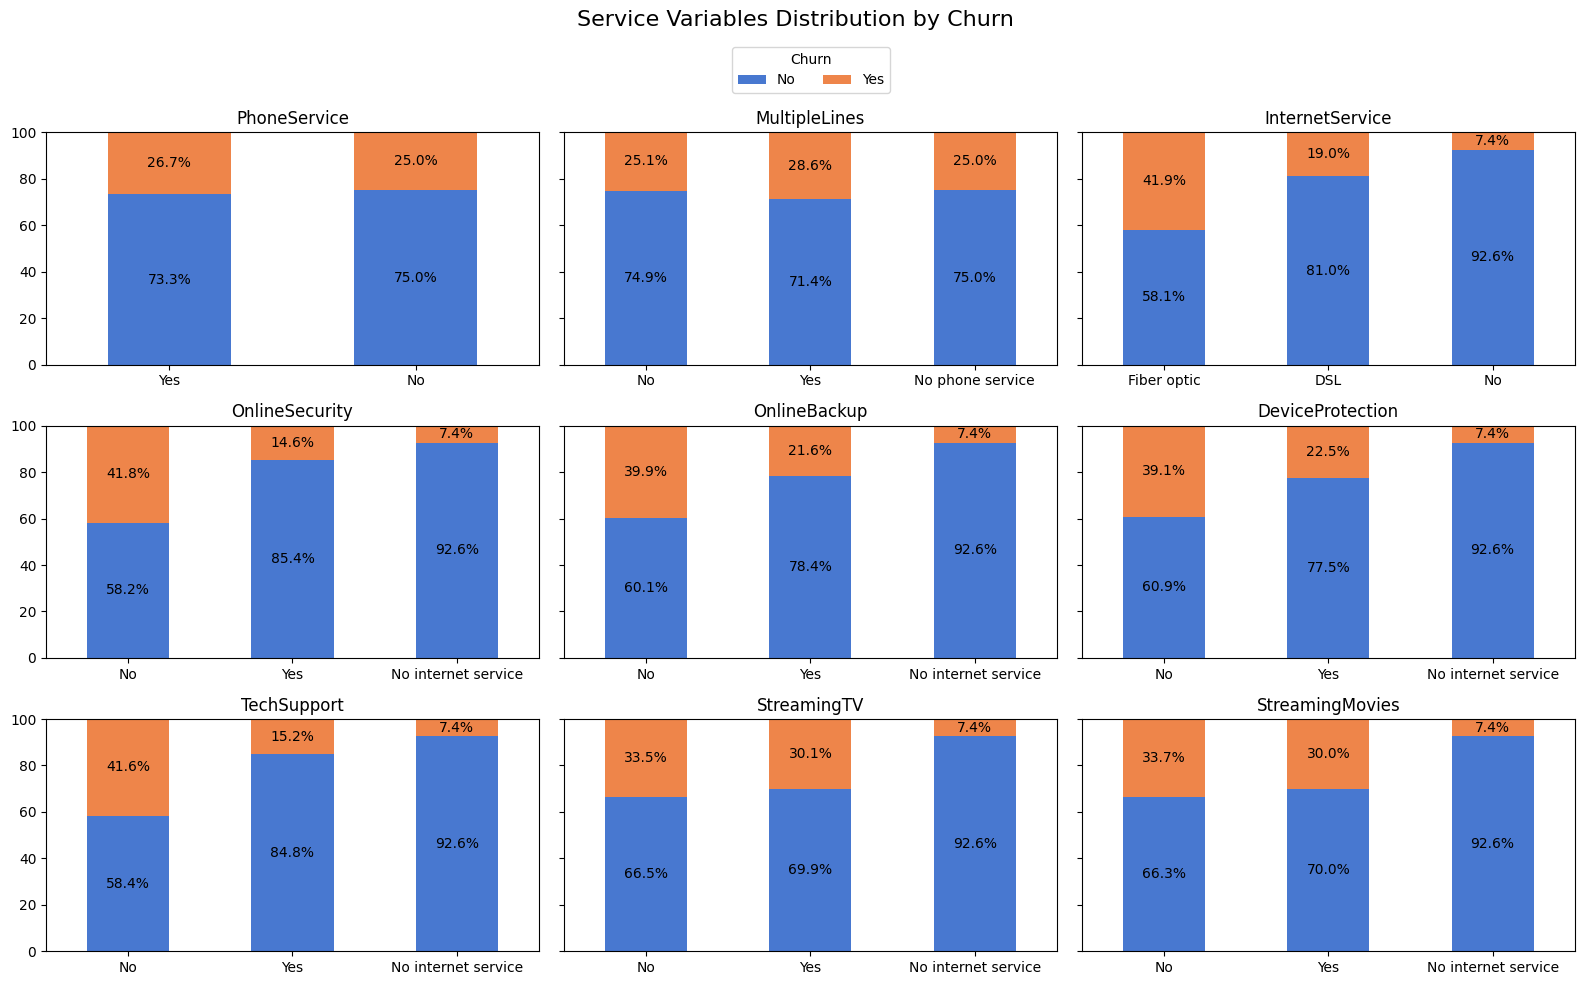

In [139]:
# distribution by churn
fig, axes = plt.subplots(3, 3, figsize = (16,10), sharey=True)

distribution_percentage_by_churn_chart_v2(axes, services_columns)

plt.suptitle("Service Variables Distribution by Churn", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

- Churn rates for phone services are about equal regardless of whether a customer has phone service or multiple lines
- Customers with no internet service have the lowest churn rate (7.4%)
- Internet service: Fiber optic has 2x churn rate of DSL
- Online Security, online backup, device protection, tech support: churn rate for non-users ranges from 39.1% to 41.8%, 14.6% to 22.5% for users. Security and support add-ons appear to be retention factors - customers who use them churn significantly less.
- Streaming TV and movies: churn rates for both groups are similar, with ~33% for non-users and ~30% for users 


In [140]:
print(f"Chi-square test of services variables & Churn at {1-alpha:.0%} significance level")
chi2_test(services_columns)

Chi-square test of services variables & Churn at 95% significance level


,feature,p_value,dependent
3,OnlineSecurity,0.000,True
6,TechSupport,0.000,True
2,InternetService,0.000,True
4,OnlineBackup,0.000,True
5,DeviceProtection,0.000,True
8,StreamingMovies,0.000,True
7,StreamingTV,0.000,True
1,MultipleLines,0.004,True
0,PhoneService,0.350,False


### 4.3.3 Customer account information

In [141]:
print(f"Categorical variables: {categorical_columns}")
account_columns = categorical_columns[-3:]
print(f"Account variables: {account_columns}")

Categorical variables: Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService',
       'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup',
       'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies',
       'Contract', 'PaperlessBilling', 'PaymentMethod'],
      dtype='str')
Account variables: Index(['Contract', 'PaperlessBilling', 'PaymentMethod'], dtype='str')


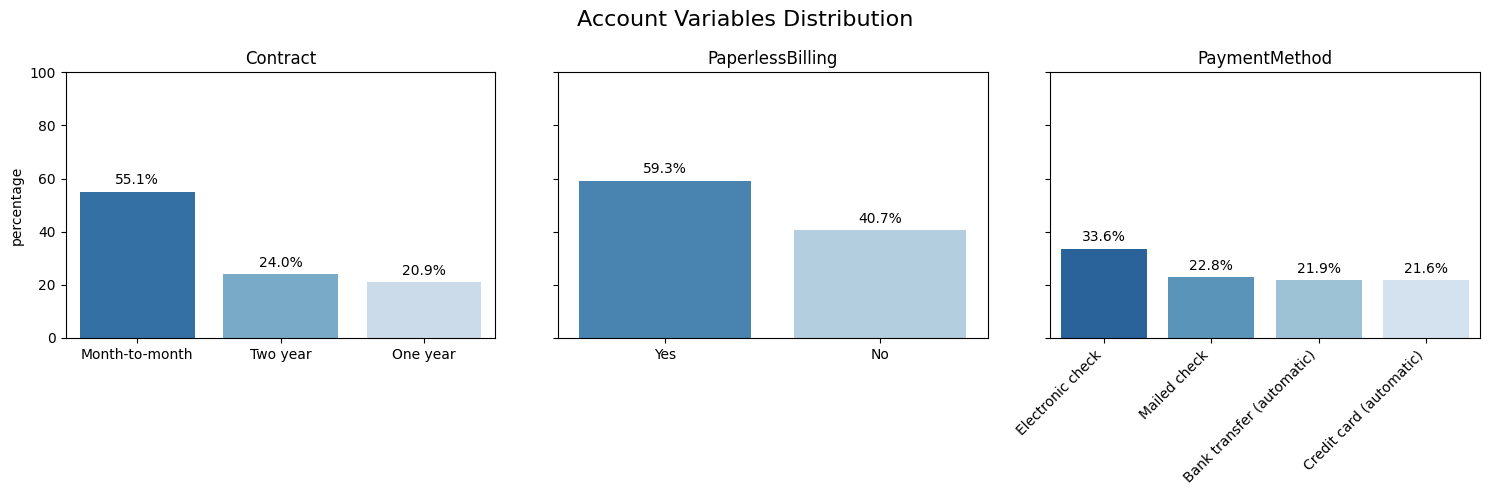

In [142]:
# distribution
fig, axes = plt.subplots(1, 3, figsize=(5 * len(account_columns), 5), sharey=True)

distribution_percentage_chart(axes, account_columns)
plt.xticks(rotation=45, ha='right')
plt.suptitle("Account Variables Distribution", fontsize=16)

plt.tight_layout()
plt.show()

- Contract: 55% of customers are on a month-to-month contract, 
- Paperless billing: almost 60% of customers
- Payment methods: 1/3 of customers use electronic checks, while the rest of the methods - mailed checks, automatic bank transfers, automatic credit cards - are at ~22%

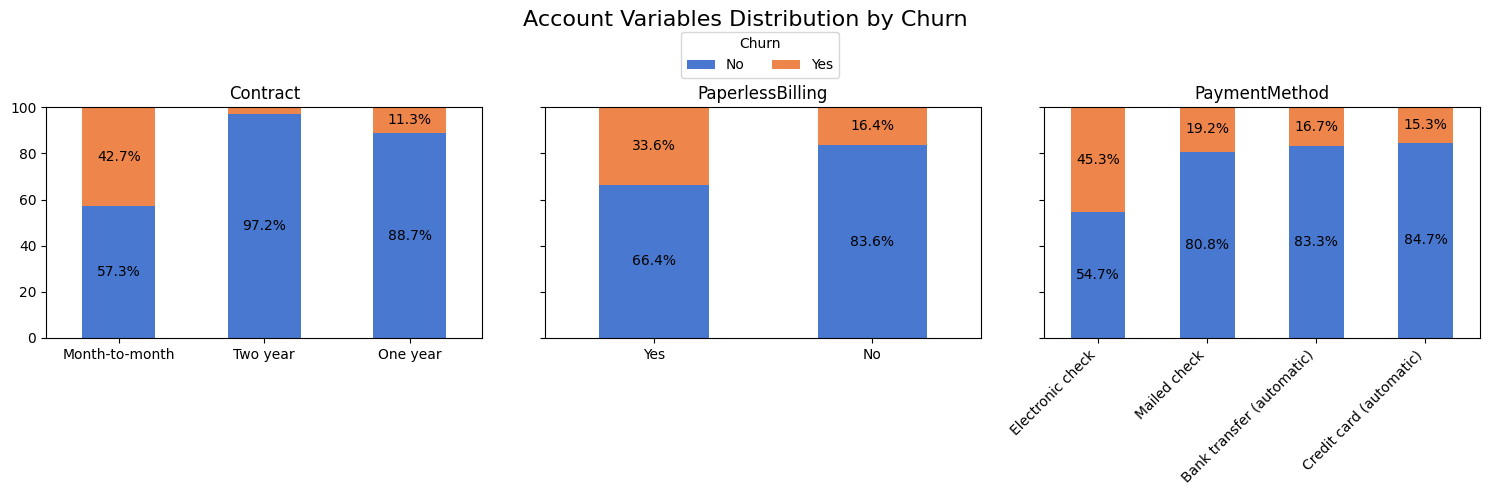

In [143]:
# distribution by churn
fig, axes = plt.subplots(1, 3, figsize=(5 * len(account_columns), 5), sharey=True)

distribution_percentage_by_churn_chart_v2(axes, account_columns)
plt.xticks(rotation=45, ha='right')

plt.suptitle("Account Variables Distribution by Churn", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig("images/account_variables_distribution_by_churn.png", dpi=300, bbox_inches="tight")
plt.show()

- Contract: churn rates vary a lot based on contract type: customers with a two-year contract are least likely to churn (2.8% rate), while a month-to-month type's churn rate is 42.7% 
- Paperless billing: paperless billing has 2x churn rate - 33.6% vs 16.4% for non-paperless
- Customers who use electronic checks, similarly, have a higher rate of churn

In [144]:
print(f"Chi-square test of account variables & Churn at {1-alpha:.0%} significance level")
chi2_test(account_columns)

Chi-square test of account variables & Churn at 95% significance level


,feature,p_value,dependent
0,Contract,0.0,True
2,PaymentMethod,0.0,True
1,PaperlessBilling,0.0,True


## 4.4 Correlation analysis

As the data types are mixed and include categorical, continuous and mixed data pairs, '[associations](https://shakedzy.xyz/dython/modules/nominal/)' from 'dython' library will be used for the convenience of building a correlation matrix. The following methods will be used:
- Pearson's R for continuous-continuous cases 
- Correlation Ratio for categorical-continuous cases 
- Cramer's V for categorical-categorical cases


In [145]:
correlation_matrix = associations(df.loc[:, df.columns != "customerID"], compute_only=True, cramers_v_bias_correction=False)["corr"]

In [146]:
mask = correlation_matrix.where(np.tril(np.ones(correlation_matrix.shape)).astype(bool))
mask

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
gender,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,0.001434,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Partner,0.001094,0.016571,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Dependents,0.010038,0.210129,0.451958,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
tenure,0.005285,0.015683,0.381912,0.163386,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PhoneService,0.007034,0.007739,0.017916,0.000552,0.007877,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
MultipleLines,0.010314,0.146730,0.144302,0.025025,0.343997,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
InternetService,0.011202,0.264920,0.001277,0.178412,0.037532,0.452255,0.396740,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineSecurity,0.016344,0.210728,0.151911,0.192981,0.336994,0.175668,0.229450,0.724367,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OnlineBackup,0.013095,0.182546,0.153303,0.161155,0.377006,0.172421,0.245074,0.707177,0.718407,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


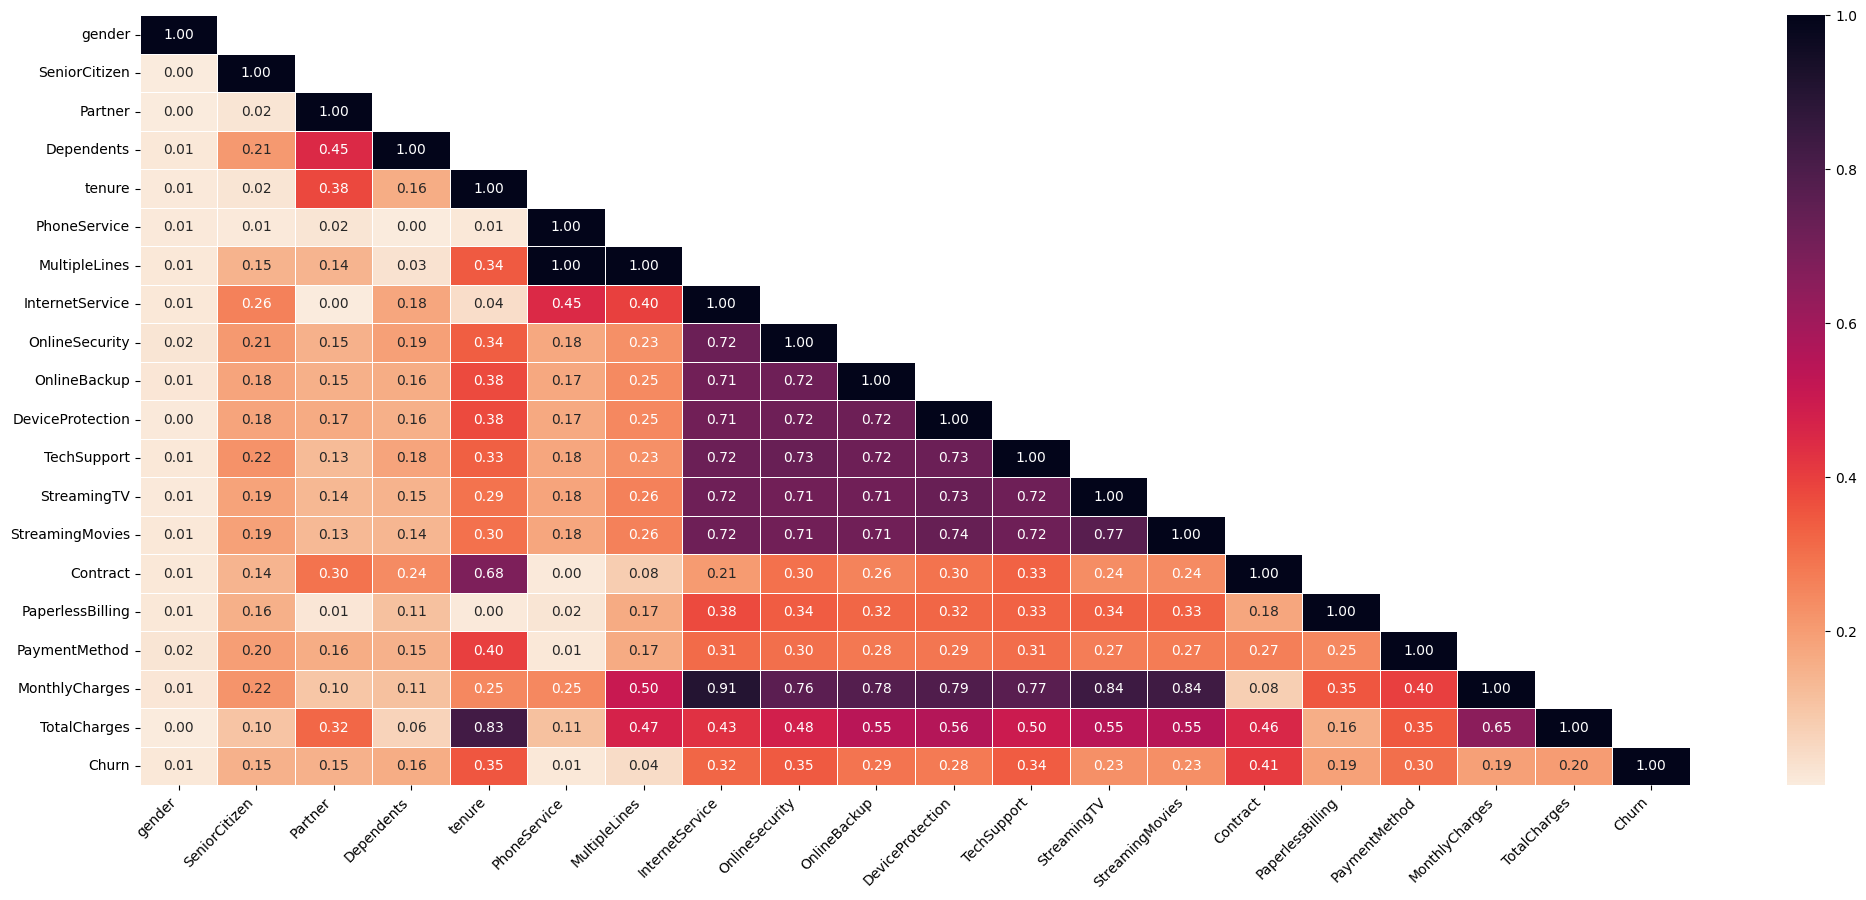

In [147]:
plt.figure(figsize=(25, 10))
ax = sns.heatmap(mask, annot=True, linewidth=.5, fmt=".2f", cmap='rocket_r')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
ax.grid(False)

- Demographics variables in most cases have weak correlation with other categorical and numerical variables
- There appears to be multicollinearity across services variables, such as InternetService / OnlineSecurity / OnlineBackup / DeviceProtection / TechSupport / StreamingTV / StreamingMovies, with their correlation coefficients being more than 0.7
- Monthly charges variables correlate strongly with services variables mentioned above (0.76+), with the highest correlation with InternetService at 0.91

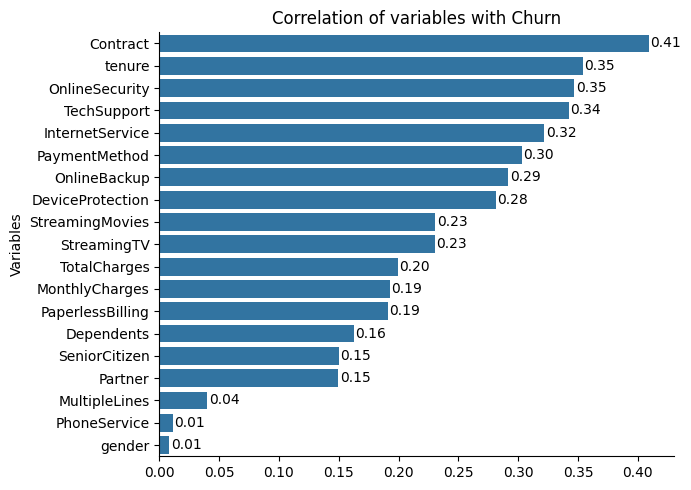

In [148]:
churn_corr = mask.iloc[-1, 0:-1].sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(7, 5))
sns.barplot(x=churn_corr.values, y=churn_corr.index, orient='h')
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1)
ax.set_title('Correlation of variables with Churn')
ax.set_ylabel('Variables')
sns.despine()
plt.tight_layout()
plt.show()

- Churn's 2 highest correlations are with Contract and tenure variables
- Internet-related service variables have correlation with churn ranging from 0.23 to 0.35
- Monthly and total charges have correlation coefficients at 0.19 and 0.20, respectively
- Phone-related service variables and demographics variables have the lowest correlations with churn

# 5 Data preprocessing

Before training, the data requires preprocessing: encoding categorical variables, splitting into train/test sets, and scaling numerical features.

In [149]:
# create a copy of data with customer id removed, and convert churn from string to integer
df2 = df.drop(columns='customerID')
df2["Churn"]= df["Churn"].map({'No': 0, 'Yes': 1})
df2.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [150]:
# 1. encoding categorical variables
df_dummies = pd.get_dummies(df2, drop_first=True) # using drop_first to solve the dummy variable trap and remove multicollinearity primarily for LogReg
df_dummies.head()

,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,SeniorCitizen_Yes,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,1,29.85,29.85,0,False,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
1,34,56.95,1889.50,0,True,False,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
2,2,53.85,108.15,1,True,False,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
3,45,42.30,1840.75,0,True,False,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
4,2,70.70,151.65,1,False,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Splitting the data:
- `stratify=y` will be used to ensure that 73.4%/26.6% split of churn remains in the train and test datasets

In [151]:
# 2. split data
y = df_dummies['Churn']
X = df_dummies.drop(columns = ['Churn'])
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [152]:
# ensuring that the split remains in both datasets
print(f"y_train: {y_train.value_counts(normalize=True).round(2).to_dict()}")
print(f"y_test: {y_test.value_counts(normalize=True).round(2).to_dict()}")

y_train: {0: 0.73, 1: 0.27}
y_test: {0: 0.73, 1: 0.27}


Scaling features:
- StandardScaler will be used to standardize numeric features: $z = \frac{x-\mu}{\sigma}$, where $x$ is original value, $\mu$ is the mean and $\sigma$ is the standard deviation

In [153]:
# 3. scaling features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Churn prediction analysis

## 6.1 Baseline - Logistic regression
A binomial logistic regression will be used as a baseline model. It uses the sigmoid function to map input variables into probabilities (0 to 1) forming a sigmoid / logistic curve and is used for classification tasks.
The sigmoid function:
$$p=\sigma(z)= \frac{1}{1+e^{-z}},$$
where $p$ is the predicted probability that a customer will churn, $z$ is the linear regression equation.

The linear equation:
$$z = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n,$$
where $\beta_0$ is the intercept, $\beta_1, \beta_2, ..., \beta_n$ are the coefficients of the input variables, $x_1, x_2, ..., x_n$ are the input variables

By substituting \(z\) into the sigmoid function, we get the complete logistic regression formula:
$$p=\sigma(z)= \frac{1}{1+e^{-(\beta_0 + \beta_1 x_1 + \beta_2 x_2 + ... + \beta_n x_n)}}.$$

Model:
- As discussed in 4.1, class imbalance is observed in the target variable.
- `class_weight='balanced'` is used to penalize the model more heavily for misclassifying the minority class:
$$w_j = \frac{n_{samples}}{n_{classes} \cdot n_j},$$
where $w_j$ is the weight for class j, $n_{samples}$ is the total number of samples (5625 in the train dataset), $n_{classes}$ is the number of classes (2), and $n_j$ is the number of samples in class j (4130 for Churn=0 and 1495 for Churn=1).

In [154]:
# Initialize and train the model
model_lr = LogisticRegression(class_weight='balanced', random_state=42)
model_lr.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr = model_lr.predict(X_test_scaled)
probabilities_lr = model_lr.predict_proba(X_test_scaled)

Since there is class imbalance, classic accuracy metric (the ratio of the sum of true positives and negatives to total) shouldn't be used.

- Precision: of all observations predicted as class X, the share that actually belongs to class X
- Recall: the ratio of correctly predicted positive observations to all observations in the actual class
- **F1-score** - the weighted average (harmonic mean) of Precision and Recall

$$F1 score = 2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$$

In [155]:
report_lr = classification_report(y_test, y_pred_lr, output_dict=True)
report_lr = pd.DataFrame.from_dict(report_lr)
with pd.option_context('display.precision', 2):
    print(report_lr)

                 0       1  accuracy  macro avg  weighted avg
precision     0.91    0.49      0.73       0.70          0.79
recall        0.70    0.80      0.73       0.75          0.73
f1-score      0.79    0.61      0.73       0.70          0.74
support    1033.00  374.00      0.73    1407.00       1407.00


Area Under the Receiver Operating Characteristic Curve (AUC-ROC): 
- The ROC curve plots the true positive rate against the false positive rate at various thresholds. 
- AUC-ROC measures the area under this curve which provides an aggregate measure of a model's performance across different classification thresholds.

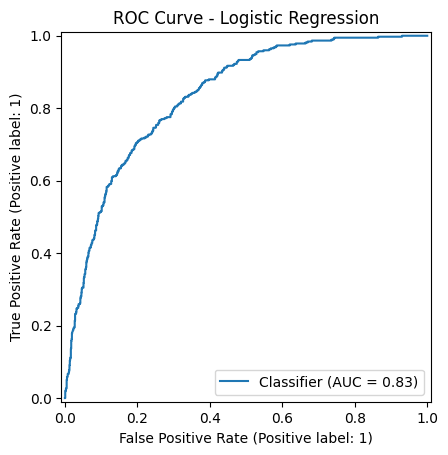

In [156]:
y_proba_lr = probabilities_lr[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba_lr)
plt.title('ROC Curve - Logistic Regression')
plt.show()

In [157]:
auc_roc_lr = roc_auc_score(y_test, y_proba_lr)
print(f"AUC-ROC: {auc_roc_lr:.4f}")

AUC-ROC: 0.8350


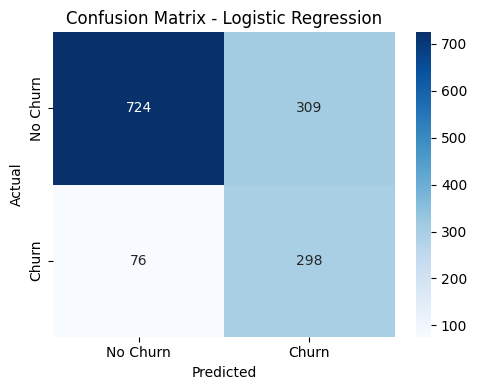

In [158]:
cnf_matrix_lr = metrics.confusion_matrix(y_test, y_pred_lr)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cnf_matrix_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()

In [159]:
tn_lr, fp_lr, fn_lr, tp_lr = cnf_matrix_lr.ravel()
print(f"True Negatives (correct no-churn values): {tn_lr}, False Positives (actual no-churn values predicted as churn): {fp_lr}")
print(f"False Negatives (actual churn values incorrectly predicted as no-churn): {fn_lr}, True Positives (correct churn values): {tp_lr}")

True Negatives (correct no-churn values): 724, False Positives (actual no-churn values predicted as churn): 309
False Negatives (actual churn values incorrectly predicted as no-churn): 76, True Positives (correct churn values): 298


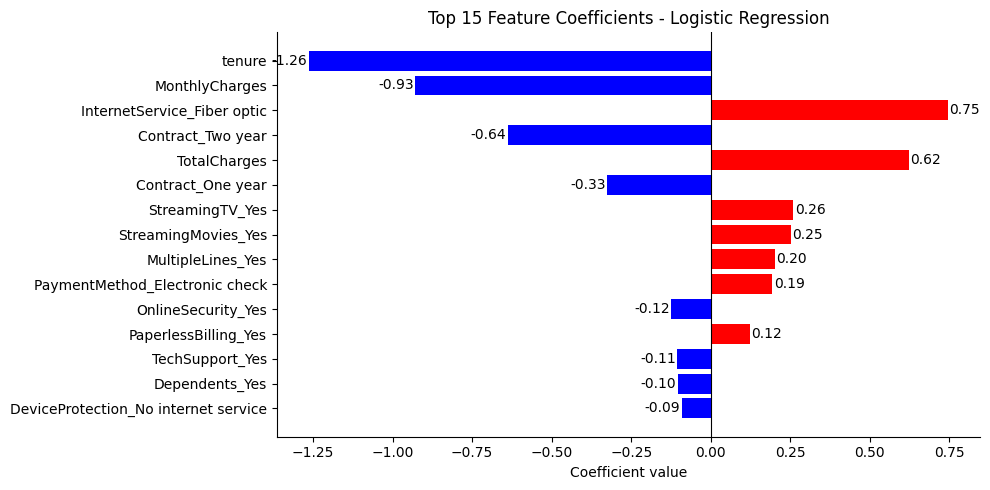

In [160]:
coefs = pd.Series(model_lr.coef_[0], index=X.columns.values)
coefs_sorted = coefs.reindex(coefs.abs().sort_values(ascending=False).index)
top_coefs = coefs_sorted.head(15)

fig, ax = plt.subplots(figsize=(10, 5))

colors = ['red' if c > 0 else 'blue' for c in top_coefs]
plt.barh(top_coefs.index[::-1], top_coefs.values[::-1], color=colors[::-1])
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 Feature Coefficients - Logistic Regression')
plt.xlabel('Coefficient value')
sns.despine()
plt.tight_layout()
plt.show()

Checking for possible reasons of Internet service = Fiber optic having a positive relationship with churn:

In [161]:
table = pd.pivot_table(df, values=['MonthlyCharges'], index=['InternetService','Contract'], aggfunc=['mean','count'])
table

mean          count
                               MonthlyCharges MonthlyCharges
InternetService Contract                                    
DSL             Month-to-month      50.219501           1223
                One year            61.396754            570
                Two year            70.507303            623
Fiber optic     Month-to-month      87.021194           2128
                One year            98.779499            539
                Two year           104.571445            429
No              Month-to-month      20.409542            524
                One year            20.822590            363
                Two year            21.773697            633

Model coefficients:
- tenure and monthly charges have the biggest negative relation with churn, while total charges variable has a positive one, which is probably due to it being roughly equal to tenure x monthly charges (multicollinearity). This issue will be addressed in the next modeling iterations.
- two-year and one-year contracts have a negative relationship with churn, indicating that a longer contract makes customers less likely to churn.
- Fiber optic has the highest positive coefficient. While being a better technology than DSL, it is also more expensive, which may lead to a customer churning. Customers with fiber optic also have a higher ratio of month-to-month contracts to year-based ones, which may also be a driver of churn (see table below).
- Streaming TV, Streaming Movies and Multiple lines services have a positive relation with churn. For streaming, possible reasons of churn can include content fragmentation and costs.

In [162]:
print(f"Logistic regression baseline achieves AUC-ROC of {auc_roc_lr:.4f} and F1-score of {report_lr.loc['f1-score', '1']:.2f} for the Churn=1. These will serve as the benchmark for subsequent models.")

Logistic regression baseline achieves AUC-ROC of 0.8350 and F1-score of 0.61 for the Churn=1. These will serve as the benchmark for subsequent models.


## 6.2 Logistic Regression with CV tuning

LogisticRegressionCV performs logistic regression with built-in cross-validation, testing multiple values of $C$ (the inverse regularization strength). A smaller C increases regularization strength, penalizing large coefficients; a larger C reduces regularization, allowing the model to fit training data more closely. In the default LogisticRegression model, C equals 1. LogisticRegressionCV chooses the best-performing C, here based on ROC-AUC score. 10 values of C are tested on a log scale from 1e-4 to 1e4 using 5-fold cross-validation.

In [163]:
# Initialize and train the model
model_cv = LogisticRegressionCV(
    Cs=10,           # 10 values on a log scale from 1e-4 to 1e4
    cv=5,            # 5-fold cross-validation
    l1_ratios=(0,), # specifies L2 regularization (equivalent to the deprecated penalty='l2' in sklearn 1.8)
    scoring='roc_auc',
    class_weight='balanced',
    max_iter=10000,
    random_state=42,
    use_legacy_attributes=False # opt into new sklearn 1.10 behavior
)
model_cv.fit(X_train_scaled, y_train)

# Make predictions
y_pred_cv = model_cv.predict(X_test_scaled)
probabilities_cv = model_cv.predict_proba(X_test_scaled)

print(model_cv.C_)

2.782559402207126


In [164]:
report_cv = classification_report(y_test, y_pred_cv, output_dict=True)
report_cv = pd.DataFrame.from_dict(report_cv)
with pd.option_context('display.precision', 2):
    print(report_cv)

                 0       1  accuracy  macro avg  weighted avg
precision     0.90    0.49      0.73       0.70          0.79
recall        0.70    0.80      0.73       0.75          0.73
f1-score      0.79    0.61      0.73       0.70          0.74
support    1033.00  374.00      0.73    1407.00       1407.00


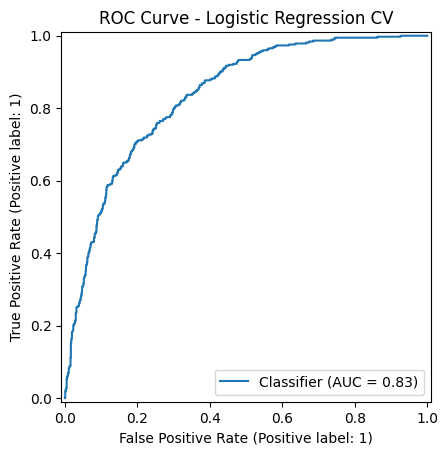

In [165]:
y_proba_cv = probabilities_cv[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba_cv)
plt.title('ROC Curve - Logistic Regression CV')
plt.show()

In [166]:
auc_roc_cv = roc_auc_score(y_test, y_proba_cv)
print(f"AUC-ROC: {auc_roc_cv:.4f}")

AUC-ROC: 0.8347


In [167]:
cnf_matrix_cv = metrics.confusion_matrix(y_test, y_pred_cv)
tn_cv, fp_cv, fn_cv, tp_cv = cnf_matrix_cv.ravel()
print(f"True Negatives (correct no-churn values): {tn_cv}, False Positives (actual no-churn values predicted as churn): {fp_cv}")
print(f"False Negatives (actual churn values incorrectly predicted as no-churn): {fn_cv}, True Positives (correct churn values): {tp_cv}")

True Negatives (correct no-churn values): 723, False Positives (actual no-churn values predicted as churn): 310
False Negatives (actual churn values incorrectly predicted as no-churn): 76, True Positives (correct churn values): 298


In [168]:
print(f"""• LogisticRegressionCV performs on the same level as default LogisticRegression, with almost equal AUC-ROC scores ({auc_roc_lr:.4f} and {auc_roc_cv:.4f} for LR and LR CV,  
respectively), F1-scores ({report_lr.loc['f1-score', '0']:.2f} and {report_cv.loc['f1-score', '0']:.2f} for Churn=0, {report_lr.loc['f1-score', '1']:.2f} and {report_cv.loc['f1-score', '1']:.2f} for Churn=1), and the count of True Negatives and True Positives 
in the confusion matrix.""") 
print(f"""• Since the optimal C found by cross-validation equals {model_cv.C_:.2f}, which is close to the default C=1, the coefficient structure remains virtually 
unchanged and is not repeated here.""")

• LogisticRegressionCV performs on the same level as default LogisticRegression, with almost equal AUC-ROC scores (0.8350 and 0.8347 for LR and LR CV,  
respectively), F1-scores (0.79 and 0.79 for Churn=0, 0.61 and 0.61 for Churn=1), and the count of True Negatives and True Positives 
in the confusion matrix.
• Since the optimal C found by cross-validation equals 2.78, which is close to the default C=1, the coefficient structure remains virtually 
unchanged and is not repeated here.


## 6.3 Random Forest 
Random forest is an algorithm that builds multiple decision trees on various sub-samples of the dataset (bootstrapping) and randomly chooses a subset of features to consider at each step (random feature selection). The output is the class selected by most trees.

Unlike Logistic regression, it is a non-linear model and does not require scaling. 

Default random forest:

In [169]:
model_rf_default = RandomForestClassifier(n_estimators=100, #default total number of decision trees
                              class_weight='balanced',
                              oob_score = True, # Uses out-of-bag samples to estimate model performance.
                              n_jobs = -1,
                              random_state = 42)
model_rf_default.fit(X_train, y_train)
y_pred_rf_default = model_rf_default.predict(X_test)
print(f"Out-of-Bag Score: {model_rf_default.oob_score_:.4f}")
probabilities_rf_default = model_rf_default.predict_proba(X_test)
y_proba_rf_default = probabilities_rf_default[:, 1]
auc_roc_rf_default = roc_auc_score(y_test, y_proba_rf_default)
print(f"AUC-ROC: {auc_roc_rf_default:.4f}")

Out-of-Bag Score: 0.7881
AUC-ROC: 0.8184


As the AUC-ROC score of random forest is slightly worse than the baseline model, RandomizedSearchCV will be used for hyperparameter tuning. It performs a random search over a specified parameter grid. 
But prior to that, we need to set an upper limit for the number of trees since after a certain threshold performance gains become negligible but computing time increases.
- `n_estimators` choice: iterate over 50 - 1000 range with a step of 50. An Out-of-Bag (OOB) score can be used to evaluate a model's predictive accuracy on data it has never seen, without needing a separate validation set. 

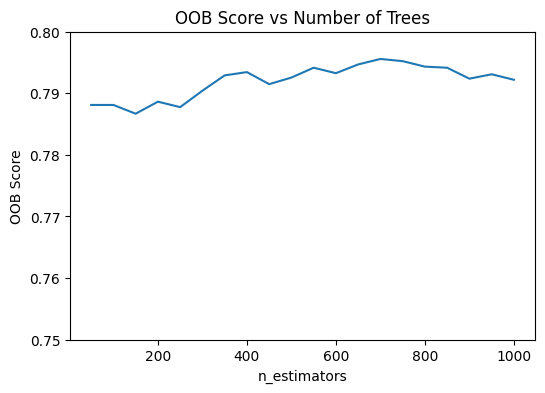

In [170]:
oob_scores = []
n_estimators_range = range(50, 1001, 50)

for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, class_weight='balanced',
                                oob_score=True, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    oob_scores.append(rf.oob_score_)

plt.figure(figsize=(6, 4))
plt.plot(n_estimators_range, oob_scores)
plt.xlabel('n_estimators')
plt.ylabel('OOB Score')
plt.title('OOB Score vs Number of Trees')
plt.ylim(0.75,0.8)
plt.show()

RandomizedSearchCV parameters:
- `n_estimators` - the number of trees. As seen in the plot above, after ~400 trees the OOB score stabilizes. Therefore, `n_estimators` will be capped at 400 in the hyperparameter search for computational efficiency.
- `max_depth` - the number of splits that each decision tree is allowed to make. Setting a higher value for max_depth can lead to overfitting, while setting it too low can lead to underfitting. Here, default option (`None`) and range of 10-30 with the step of 10 are used.
- `min_samples_split` - the minimum number of samples required to split an internal node. Higher values prevent the model from learning overly specific patterns. Values of 2–20 cover the range from no restriction (default=2) to moderate regularization given the train size of ~5600 samples.
- `min_samples_leaf` - the minimum number of samples required to be at a leaf node. Acts as smoothing: higher values create more generalized models. Values of 1–10 are tested, as larger values would overly restrict tree growth on this dataset.
- `max_features` - the number of features to consider when looking for the best split. If `"sqrt"`, then `max_features=sqrt(n_features)`; if `"log2"`, then `max_features=log2(n_features)`. As sqrt(26) = 5.1 and log2(26) = 4.7, several other options were added: 0.3 (~8 features), 0.5 (~13 features), 0.7 (~18 features), and None (all 26 features)

For more details on parameters, see [sklearn docs](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

In [171]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2', None, 0.3, 0.5, 0.7]
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
search.fit(X_train, y_train)
print("Best params:", search.best_params_)
print("Best CV AUC-ROC:", search.best_score_)

Best params: {'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 5, 'max_features': 'log2', 'max_depth': 10}
Best CV AUC-ROC: 0.8474078243053924


In [172]:
model_rf = RandomForestClassifier(n_estimators=200,
                              class_weight='balanced',
                              oob_score = True, # Uses out-of-bag samples to estimate model performance.
                              n_jobs = -1,
                              random_state = 42,
                              min_samples_split=20,
                              min_samples_leaf=5,
                              max_features='log2',
                              max_depth=10)
model_rf.fit(X_train, y_train)
y_pred_rf = model_rf.predict(X_test)
print(f"Out-of-Bag Score: {model_rf.oob_score_:.4f}")
probabilities_rf = model_rf.predict_proba(X_test)

Out-of-Bag Score: 0.7673


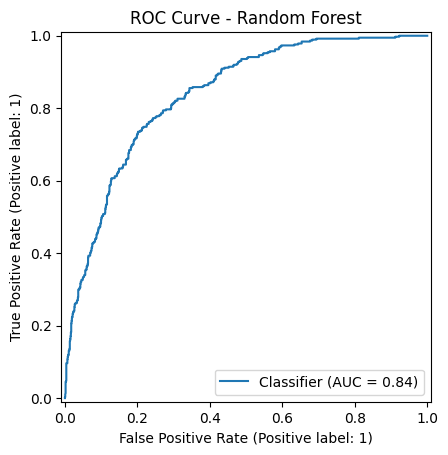

In [173]:
y_proba_rf = probabilities_rf[:, 1]
RocCurveDisplay.from_predictions(y_test, y_proba_rf)
plt.title('ROC Curve - Random Forest')
plt.show()

In [174]:
auc_roc_rf = roc_auc_score(y_test, y_proba_rf)
print(f"AUC-ROC: {auc_roc_rf:.4f}")
print(f"After tuning, AUC-ROC has improved from {auc_roc_rf_default:.4f} to {auc_roc_rf:.4f}")

AUC-ROC: 0.8380
After tuning, AUC-ROC has improved from 0.8184 to 0.8380


In [175]:
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
report_rf = pd.DataFrame.from_dict(report_rf)
with pd.option_context('display.precision', 2):
    print(report_rf)

                 0       1  accuracy  macro avg  weighted avg
precision     0.90    0.52      0.75       0.71          0.80
recall        0.74    0.78      0.75       0.76          0.75
f1-score      0.82    0.63      0.75       0.72          0.76
support    1033.00  374.00      0.75    1407.00       1407.00


In [176]:
print(f"""• The best CV AUC-ROC ({search.best_score_:.4f}) is slightly higher than the test AUC-ROC ({auc_roc_rf:.4f}). This is expected: cross-validation score is optimized during search 
and averaged over training folds, while the test score reflects performance on fully unseen data. A small gap indicates no significant overfitting.
• Random forest AUC-ROC ({auc_roc_rf:.4f}) is basically the same as logistic regressions AUC-ROC ({auc_roc_lr:.4f}).
• F1-scores have slightly increased for both Churn=0 ({report_lr.loc['f1-score', '0']:.2f} -> {report_rf.loc['f1-score', '0']:.2f}) and Churn=1 ({report_lr.loc['f1-score', '1']:.2f} -> {report_rf.loc['f1-score', '1']:.2f}).""")

• The best CV AUC-ROC (0.8474) is slightly higher than the test AUC-ROC (0.8380). This is expected: cross-validation score is optimized during search 
and averaged over training folds, while the test score reflects performance on fully unseen data. A small gap indicates no significant overfitting.
• Random forest AUC-ROC (0.8380) is basically the same as logistic regressions AUC-ROC (0.8350).
• F1-scores have slightly increased for both Churn=0 (0.79 -> 0.82) and Churn=1 (0.61 -> 0.63).


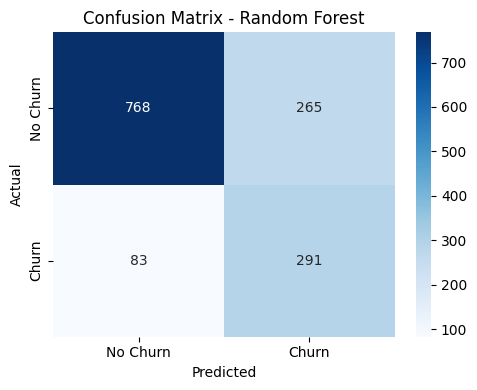

In [177]:
cnf_matrix_rf = metrics.confusion_matrix(y_test, y_pred_rf)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cnf_matrix_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

In [178]:
tn_rf, fp_rf, fn_rf, tp_rf = cnf_matrix_rf.ravel()
print(f"True Negatives (correct no-churn values): {tn_rf}, False Positives (actual no-churn values predicted as churn): {fp_rf}")
print(f"False Negatives (actual churn values incorrectly predicted as no-churn): {fn_rf}, True Positives (correct churn values): {tp_rf}")
print(f"Compared to Logistic regression, the count of true negatives has increased: {tn_lr}->{tn_rf}, while the count of true positives has stayed almost same: {tp_lr}->{tp_rf}")

True Negatives (correct no-churn values): 768, False Positives (actual no-churn values predicted as churn): 265
False Negatives (actual churn values incorrectly predicted as no-churn): 83, True Positives (correct churn values): 291
Compared to Logistic regression, the count of true negatives has increased: 724->768, while the count of true positives has stayed almost same: 298->291


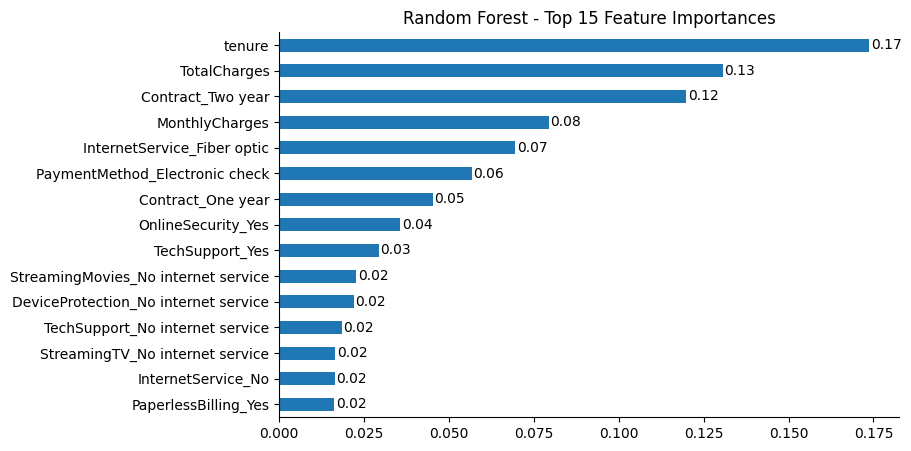

In [179]:
importance = (pd.Series(model_rf.feature_importances_, index=X.columns).sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(8, 5))

importance.tail(15).plot(kind='barh')

plt.title("Random Forest - Top 15 Feature Importances")
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1)
sns.despine()
plt.show()

- For random forest model, tenure, total charges, two-year contract, monthly charges and internet service = fiber optic variables are the most important predictors.
- The results are similar to those achieved by Logistic Regression. This may be due to the dataset being relatively small and linearly separable.

### 6.3.1 Random Forest without TotalCharges variable
- As discussed in section 6.1, TotalCharges is derived from tenure x MonthlyCharges, thus removing it might improve the model in terms of feature importance. This will be tested in the current section.

In [180]:
X_train_wo_total_charges = X_train.drop(columns=['TotalCharges'])
X_test_wo_total_charges = X_test.drop(columns=['TotalCharges'])
print(X_train_wo_total_charges.shape)
print(X_test_wo_total_charges.shape)

(5625, 29)
(1407, 29)


In [181]:
# same params as in 6.3
model_rf_wo_tc = RandomForestClassifier(n_estimators=200,
                              class_weight='balanced',
                              oob_score = True, # Uses out-of-bag samples to estimate model performance.
                              n_jobs = -1,
                              random_state = 42,
                              min_samples_split=20,
                              min_samples_leaf=5,
                              max_features='log2',
                              max_depth=10)
model_rf_wo_tc.fit(X_train_wo_total_charges, y_train)
y_pred_rf_wo_tc = model_rf_wo_tc.predict(X_test_wo_total_charges)
print(f"Out-of-Bag Score: {model_rf_wo_tc.oob_score_:.4f}")
probabilities_rf_wo_tc = model_rf_wo_tc.predict_proba(X_test_wo_total_charges)

Out-of-Bag Score: 0.7630


In [182]:
y_proba_rf_wo_tc = probabilities_rf_wo_tc[:, 1]
auc_roc_rf_wo_tc = roc_auc_score(y_test, y_proba_rf_wo_tc)
print(f"AUC-ROC: {auc_roc_rf_wo_tc:.4f}")

AUC-ROC: 0.8367


In [183]:
report_rf_wo_tc = classification_report(y_test, y_pred_rf_wo_tc, output_dict=True)
report_rf_wo_tc = pd.DataFrame.from_dict(report_rf_wo_tc)
with pd.option_context('display.precision', 2):
    print(report_rf_wo_tc)

                 0       1  accuracy  macro avg  weighted avg
precision     0.90    0.52      0.75       0.71          0.80
recall        0.74    0.78      0.75       0.76          0.75
f1-score      0.81    0.62      0.75       0.72          0.76
support    1033.00  374.00      0.75    1407.00       1407.00


In [184]:
cnf_matrix_rf_wo_tc = metrics.confusion_matrix(y_test, y_pred_rf_wo_tc)
tn_rf_wo_tc, fp_rf_wo_tc, fn_rf_wo_tc, tp_rf_wo_tc = cnf_matrix_rf_wo_tc.ravel()
print(f"True Negatives (correct no-churn values): {tn_rf_wo_tc}, False Positives (actual no-churn values predicted as churn): {fp_rf_wo_tc}")
print(f"False Negatives (actual churn values incorrectly predicted as no-churn): {fn_rf_wo_tc}, True Positives (correct churn values): {tp_rf_wo_tc}")
print(f"Compared to Random forest with all variables, the count of true negatives has decreased: {tn_rf}->{tn_rf_wo_tc}; the count of true positives has increased by {tp_rf_wo_tc-tp_rf}: {tp_rf}->{tp_rf_wo_tc}")

True Negatives (correct no-churn values): 763, False Positives (actual no-churn values predicted as churn): 270
False Negatives (actual churn values incorrectly predicted as no-churn): 82, True Positives (correct churn values): 292
Compared to Random forest with all variables, the count of true negatives has decreased: 768->763; the count of true positives has increased by 1: 291->292


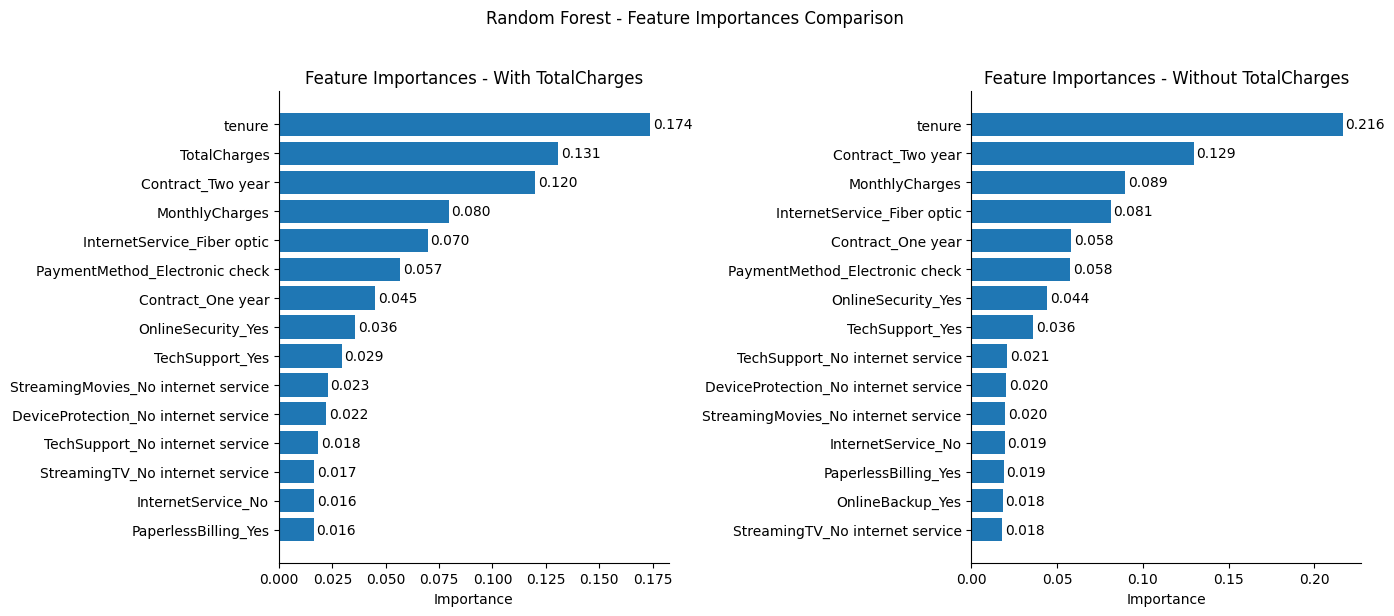

In [185]:
importance_wo_tc = (pd.Series(model_rf_wo_tc.feature_importances_, index=X_test_wo_total_charges.columns).sort_values(ascending=True))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
axes[0].barh(importance.tail(15).index, importance.tail(15).values)
axes[0].set_title('Feature Importances - With TotalCharges')
axes[0].set_xlabel('Importance')

sns.despine(ax=axes[0])
axes[1].barh(importance_wo_tc.tail(15).index, importance_wo_tc.tail(15).values)
axes[1].set_title('Feature Importances - Without TotalCharges')
axes[1].set_xlabel('Importance')
sns.despine(ax=axes[1])
plt.suptitle('Random Forest - Feature Importances Comparison', y=1.02)
for ax in axes:
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', padding=2)
plt.tight_layout()
plt.show()

In [186]:
print(f"• Removing TotalCharges to address multicollinearity did not improve model performance: \n AUC-ROC: {auc_roc_rf:.4f} for all variables vs {auc_roc_rf_wo_tc:.4f} for the dataset with TotalCharges removed.")
print(f"• F1-scores have slightly decreased for Churn=0 ({report_rf.loc['f1-score', '0']:.4f}->{report_rf_wo_tc.loc['f1-score', '0']:.4f}) and Churn=1 ({report_rf.loc['f1-score', '1']:.4f}->{report_rf_wo_tc.loc['f1-score', '1']:.4f})")
print(f"• The overall ranking of feature importance has stayed the same, but the scores of remaining features have increased due to not being diluted by TotalCharges anymore. ")

• Removing TotalCharges to address multicollinearity did not improve model performance: 
 AUC-ROC: 0.8380 for all variables vs 0.8367 for the dataset with TotalCharges removed.
• F1-scores have slightly decreased for Churn=0 (0.8153->0.8126) and Churn=1 (0.6258->0.6239)
• The overall ranking of feature importance has stayed the same, but the scores of remaining features have increased due to not being diluted by TotalCharges anymore. 


## 6.4. XGBoost

XGBoost uses gradient boosted decision trees, a supervised learning boosting algorithm that optimizes a differentiable loss function using gradient descent, fitting each new tree to the negative gradient of the loss. While random forest builds multiple independent decision trees in parallel and averages their predictions, XGBoost builds trees sequentially, where each new tree specifically attempts to correct the errors and residuals of the previous ones.

`scale_pos_weight` is XGBoost's equivalent of `class_weight='balanced'` - it weights the minority class by the ratio of negative to positive samples.

In [187]:
# calculate scale_pos_weight
scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
print(f"{scale_pos_weight:.2f}")

2.76


In [188]:
model_xgb_default = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1
)

model_xgb_default.fit(X_train, y_train)
y_pred_xgb_default = model_xgb_default.predict(X_test)

y_proba_xgb_default = model_xgb_default.predict_proba(X_test)[:,1]

report_xgb_default = classification_report(y_test, y_pred_xgb_default, output_dict=True)
report_xgb_default = pd.DataFrame.from_dict(report_xgb_default)
with pd.option_context('display.precision', 2):
    print(report_xgb_default)
auc_roc_xgb_default = roc_auc_score(y_test, y_proba_xgb_default)
print(f"AUC-ROC: {auc_roc_xgb_default:.4f}")

                 0       1  accuracy  macro avg  weighted avg
precision     0.87    0.53      0.75       0.70          0.78
recall        0.78    0.68      0.75       0.73          0.75
f1-score      0.82    0.60      0.75       0.71          0.76
support    1033.00  374.00      0.75    1407.00       1407.00
AUC-ROC: 0.8146


**Hyperparameter search**

RandomizedSearchCV parameters:
- `n_estimators` - the number of trees. Same range as Random Forest [100, 200, 300, 400], as the OOB analysis showed stabilization around 300–400 trees - a reasonable upper bound for boosting as well
- `max_depth` - the number of splits that each decision tree is allowed to make. In boosting, trees are intentionally shallow - each tree corrects only the residual error of the previous one, so deep trees quickly lead to overfitting. Default in XGBoost is 6.
 - `learning_rate` - a number between 0 and 1 (default is 0.3), which determines the rate the algorithm learns from each iteration. Smaller values require more trees and computing time but generalize better; larger values converge faster but risk overfitting. Tested range covers from conservative (0.01) to the default (0.3).
 - `subsample` - row sampling per tree. 1.0 means that all rows are used, 0.6 - 60% of the rows.
 - `colsample_bytree` - column sampling per tree. Similar to `max_features` in random forest.
 - `min_child_weight` - conceptually similar to min_samples_leaf in Random Forest, but operates on the sum of sample weights rather than sample count - relevant here since classes are weighted via scale_pos_weight.

 For more details on parameters, see [xgboost docs](https://xgboost.readthedocs.io/en/latest/parameter.html#)

In [189]:
param_dist = {
    'n_estimators': [100, 200, 300, 400],
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.05, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.5, 0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5]
}

search_xgb = RandomizedSearchCV(
    XGBClassifier(
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        n_jobs=-1
    ),
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1
)
search_xgb.fit(X_train, y_train)
print("Best params:", search_xgb.best_params_)
print("Best CV AUC-ROC:", search_xgb.best_score_)

Best params: {'subsample': 0.6, 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 5, 'learning_rate': 0.01, 'colsample_bytree': 0.6}
Best CV AUC-ROC: 0.848294962222744


In [190]:
model_xgb = XGBClassifier(
    random_state=42,
    scale_pos_weight=scale_pos_weight,
    n_jobs=-1,
    subsample=0.6, 
    n_estimators= 200, 
    min_child_weight= 5, 
    max_depth= 5, 
    learning_rate= 0.01, 
    colsample_bytree= 0.6
)

model_xgb.fit(X_train, y_train)
y_pred_xgb = model_xgb.predict(X_test)
y_proba_xgb = model_xgb.predict_proba(X_test)[:,1]
auc_roc_xgb = roc_auc_score(y_test, y_proba_xgb)
print(f"AUC-ROC: {auc_roc_xgb:.4f}")

AUC-ROC: 0.8407


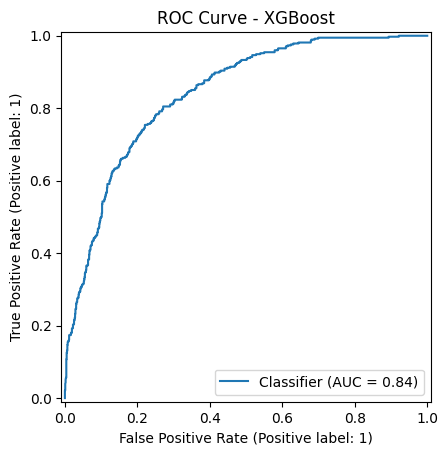

In [191]:
RocCurveDisplay.from_predictions(y_test, y_proba_xgb)
plt.title('ROC Curve - XGBoost')
plt.show()

In [192]:
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
report_xgb = pd.DataFrame.from_dict(report_xgb)
with pd.option_context('display.precision', 2):
    print(report_xgb)

                 0       1  accuracy  macro avg  weighted avg
precision     0.91    0.51      0.74       0.71          0.80
recall        0.72    0.80      0.74       0.76          0.74
f1-score      0.80    0.62      0.74       0.71          0.76
support    1033.00  374.00      0.74    1407.00       1407.00


In [193]:
print(f"XGBoost AUC-ROC {auc_roc_xgb:.4f} is slightly higher than both Logistic Regression ({auc_roc_lr:.4f}) and Random Forest ({auc_roc_rf:.4f})")
print(f"XGBoost F1-score for Churn=1 equals {report_xgb.loc['f1-score', '1']:.4f} and is higher than Logistic Regression ({report_lr.loc['f1-score', '1']:.4f}) but lower than Random Forest ({report_rf.loc['f1-score', '1']:.4f})")

XGBoost AUC-ROC 0.8407 is slightly higher than both Logistic Regression (0.8350) and Random Forest (0.8380)
XGBoost F1-score for Churn=1 equals 0.6232 and is higher than Logistic Regression (0.6075) but lower than Random Forest (0.6258)


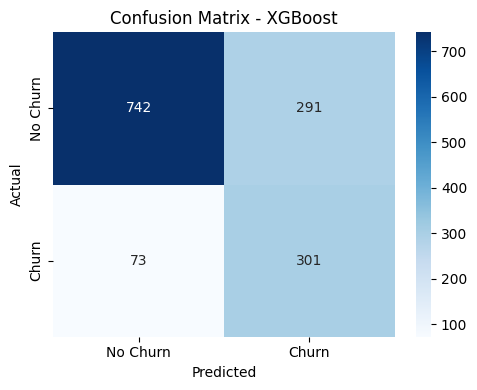

In [194]:
cnf_matrix_xgb = metrics.confusion_matrix(y_test, y_pred_xgb)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cnf_matrix_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'], ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.show()

In [195]:
tn_xgb, fp_xgb, fn_xgb, tp_xgb = cnf_matrix_xgb.ravel()
print(f"True Negatives (correct no-churn values): {tn_xgb}, False Positives (actual no-churn values predicted as churn): {fp_xgb}")
print(f"False Negatives (actual churn values incorrectly predicted as no-churn): {fn_xgb}, True Positives (correct churn values): {tp_xgb}")

True Negatives (correct no-churn values): 742, False Positives (actual no-churn values predicted as churn): 291
False Negatives (actual churn values incorrectly predicted as no-churn): 73, True Positives (correct churn values): 301


Feature importance is measured by gain - the average improvement in loss brought by a feature across all splits.

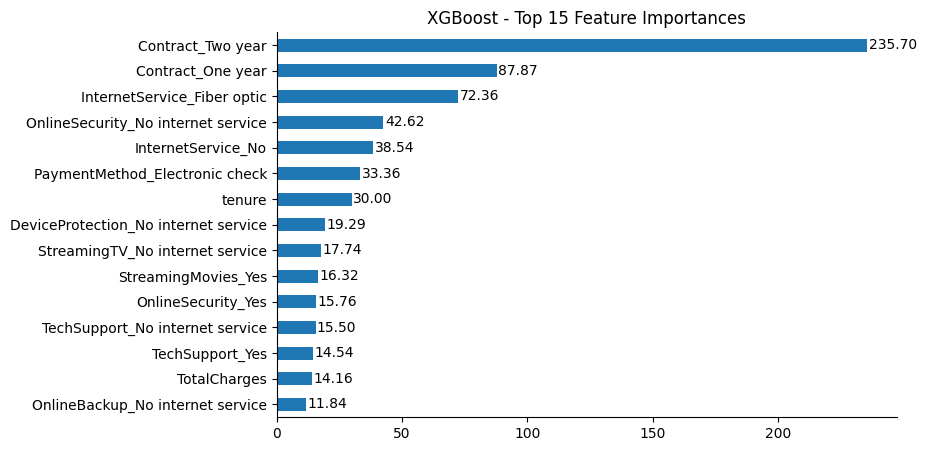

In [196]:
importance_xgb = pd.Series(model_xgb.get_booster().get_score(importance_type='gain'), name='gain').sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))

importance_xgb.tail(15).plot(kind='barh')

plt.title("XGBoost - Top 15 Feature Importances")
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f', padding=1)
sns.despine()
plt.show()

- In XGBoost, the most important features are two- and one-year contracts, internet service = fiber optic, and no internet service. 
- As opposed to both logistic regression and random forest (all variables), one-year contract variable is present, as well as no internet service feature.
- XGBoost's most important variables do not include monthly charges, which were in the list for Logistic Regression and Random Forest.

SHAP (SHapley Additive exPlanations) values assign an importance score to each feature for a specific prediction, showing how much that feature pushed the output away from the baseline average.
`TreeExplainer` computes exact SHAP values by leveraging the tree structure directly, making it both computationally efficient and exact for XGBoost.

SHAP Summary plot for top 15 features:
- Y-axis: most important features in descending order of their impact.
- X-axis: SHAP-value indicates how much the feature's value shifted the prediction away from the baseline. Positive values increase the predicted churn, negative values decrease it.
- Color: feature value, from low in blue to high in red.
- Dots: each dot represents a data point.

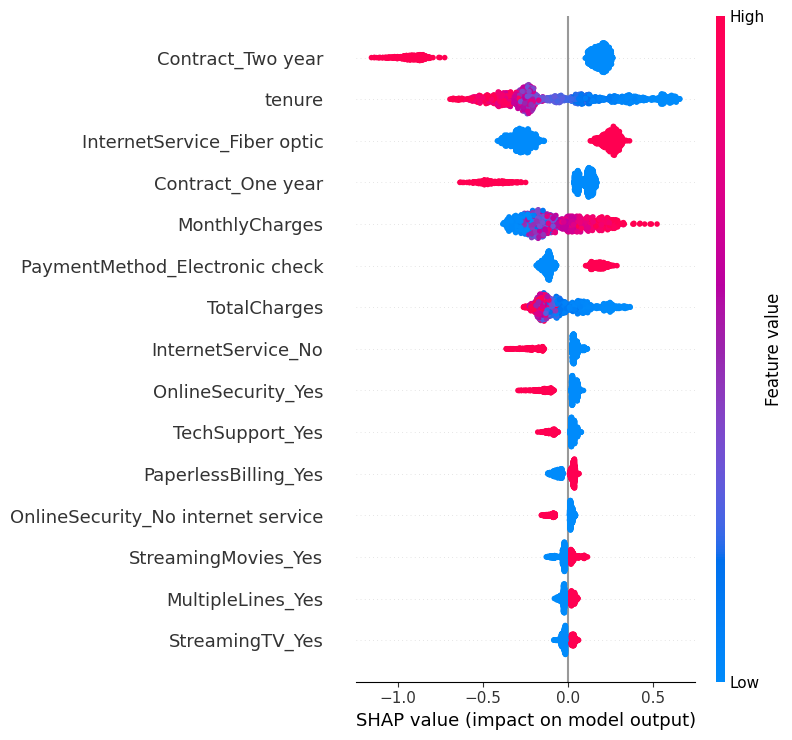

In [200]:
explainer = shap.TreeExplainer(model_xgb)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, max_display=15, show=False)
plt.savefig("images/shap_summary.png", dpi=300, bbox_inches="tight")

- The most influential features in the XGBoost model are Contract_Two year, tenure, InternetService_Fiber optic, Contract_One year, and MonthlyCharges, as they exhibit the largest mean absolute SHAP values.
- Features such as Two-year contracts, tenure, one-year contracts have, for the most part, red dots grouped in the left, and blue ones on the right. This indicates that higher feature values  for these variables / their presence decrease the probability of churn, and lower feature values / absence of one increase it
- Fiber optic option for internet service and monthly charges: higher feature values result in higher churn, and lower feature push predictions lower.

# 7. Results

In [198]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Logistic Regression CV',
              'Random Forest', 'Random Forest (no TotalCharges)', 'XGBoost'],
    'AUC-ROC': [auc_roc_lr, auc_roc_cv, auc_roc_rf, auc_roc_rf_wo_tc, auc_roc_xgb],
    'Precision (Churn=1)': [report_lr.loc['precision', '1'],
                            report_cv.loc['precision', '1'],
                            report_rf.loc['precision', '1'],
                            report_rf_wo_tc.loc['precision', '1'],
                            report_xgb.loc['precision', '1']],
    'Recall (Churn=1)': [report_lr.loc['recall', '1'],
                         report_cv.loc['recall', '1'],
                         report_rf.loc['recall', '1'],
                         report_rf_wo_tc.loc['recall', '1'],
                         report_xgb.loc['recall', '1']],
    'F1 (Churn=1)': [report_lr.loc['f1-score', '1'],
                     report_cv.loc['f1-score', '1'],
                     report_rf.loc['f1-score', '1'],
                     report_rf_wo_tc.loc['f1-score', '1'],
                     report_xgb.loc['f1-score', '1']]
}).set_index('Model').round(4)

results

,AUC-ROC,Precision (Churn=1),Recall (Churn=1),F1 (Churn=1)
Model,,,,
Logistic Regression,0.8350,0.4909,0.7968,0.6075
Logistic Regression CV,0.8347,0.4901,0.7968,0.6069
Random Forest,0.8380,0.5234,0.7781,0.6258
Random Forest (no TotalCharges),0.8367,0.5196,0.7807,0.6239
XGBoost,0.8407,0.5084,0.8048,0.6232


- All models perform similarly in terms of metrics, as seen in the table above.
- Best performing models by metric: AUC-ROC - XGBoost, Precision - Random Forest (all variables), Recall - XGBoost, F1-score - Random forest (all variables).
- For production use cases where interpretability and speed are priorities, Logistic Regression remains a strong choice. For maximizing predictive performance, XGBoost provides a marginal improvement in AUC-ROC.
- Logistic Regression and XGBoost prioritize Recall over Precision - they catch more churners but also flag more false positives. Random Forest achieves a better Precision/Recall balance, resulting in the highest F1-score. The choice between models depends on business priorities: if missing a churner is more costly than a false alarm, higher Recall (LR/XGBoost) is preferable.
- All models converge to AUC-ROC of ~0.84, suggesting the performance ceiling is set by the available features rather than the choice of algorithm.

In [199]:
results_features = pd.DataFrame({
    'Model': ['Logistic Regression', 
              'Random Forest', 'Random Forest (no TotalCharges)', 'XGBoost'],
    'Top 5 Features': [list(top_coefs.head(5).index), 
                 list(importance.tail(5).iloc[::-1].index), 
                 list(importance_wo_tc.tail(5).iloc[::-1].index), 
                 list(importance_xgb.tail(5).iloc[::-1].index)]
}).set_index('Model')

with pd.option_context('display.max_colwidth', None):
    display(results_features)

,Top 5 Features
Model,
Logistic Regression,"[tenure, MonthlyCharges, InternetService_Fiber optic, Contract_Two year, TotalCharges]"
Random Forest,"[tenure, TotalCharges, Contract_Two year, MonthlyCharges, InternetService_Fiber optic]"
Random Forest (no TotalCharges),"[tenure, Contract_Two year, MonthlyCharges, InternetService_Fiber optic, Contract_One year]"
XGBoost,"[Contract_Two year, Contract_One year, InternetService_Fiber optic, OnlineSecurity_No internet service, InternetService_No]"


- Contract type and internet service type are consistently the strongest predictors across all models, suggesting these are the primary drivers of churn in this dataset.
- For Logistic Regression, tenure / MonthlyCharges / Contract_Two year have a negative relationship with Churn, while InternetService_Fiber and TotalCharges have a positive one.
- Tenure, MonthlyCharges are present in Logistic Regression and both Random Forest models; TotalCharges is present in first two models
- Contract_One year is a top 5 feature in RandomForest (no TotalCharges) and XGBoost
- XGBoost's top features also include OnlineSecurity_No internet service and InternetService_No, which were not deemed as most important in the Logistic Regression and Random Forest. Customers with no internet service churn less - likely because they are on simpler, cheaper plans with fewer alternatives available.

Across all models, the strongest churn drivers are contract type (month-to-month vs long-term) and internet service type (fiber optic). Customers on short-term contracts with fiber optic internet and high monthly charges represent the highest-risk segment. Retention strategies should prioritize converting month-to-month customers to longer contracts and addressing satisfaction issues among fiber optic users.